In [1]:
import os

os.environ["ROBOFLOW_API_KEY"] = "J1oKKy8ww5yYkJGO3YUZ"


In [2]:
import numpy as np
import supervision as sv
import json
import os
from PIL import Image
import supervision as sv
from rfdetr import RFDETRBase
import cv2
import matplotlib.pyplot as plt
from rfdetr.util.coco_classes import COCO_CLASSES

In [3]:
DATASET_NAME = "aquatic_loss_dataset"

# Define your dataset paths
DATASET_ROOT = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"

# Train paths
train_dir_images = os.path.join(DATASET_ROOT, "train/images")
train_dir_labels = os.path.join(DATASET_ROOT, "train/labels")  # YOLO format labels
output_train_dir = os.path.join(DATASET_ROOT, "train")

# Validation paths
valid_dir_images = os.path.join(DATASET_ROOT, "valid/images")
valid_dir_labels = os.path.join(DATASET_ROOT, "valid/labels")
output_valid_dir = os.path.join(DATASET_ROOT, "valid")

# Test paths
test_dir_images = os.path.join(DATASET_ROOT, "test/images")
test_dir_labels = os.path.join(DATASET_ROOT, "test/labels")
output_test_dir = os.path.join(DATASET_ROOT, "test")


In [4]:
# Define categories for the aquatic dataset
categories = [
    {"id": 0, "name": 'fish', "supercategory": "animal"}, 
    {"id": 1, "name": 'jellyfish', "supercategory": "animal"}, 
    {"id": 2, "name": "penguin", "supercategory": "animal"}, 
    {"id": 3, "name": "puffer_fish", "supercategory": "animal"}, 
    {"id": 4, "name": "shark", "supercategory": "animal"}, 
    {"id": 5, "name": "stingray", "supercategory": "animal"}, 
    {"id": 6, "name": "starfish", "supercategory": "animal"}
]

print("Categories defined:")
for cat in categories:
    print(f"  ID {cat['id']}: {cat['name']}")


Categories defined:
  ID 0: fish
  ID 1: jellyfish
  ID 2: penguin
  ID 3: puffer_fish
  ID 4: shark
  ID 5: stingray
  ID 6: starfish


In [5]:
# ============================================================
# FORCE RELOAD MODIFIED MODULES
# ============================================================

import sys
import importlib

# Remove cached modules
if 'rfdetr.models.lwdetr' in sys.modules:
    del sys.modules['rfdetr.models.lwdetr']
if 'rfdetr.models' in sys.modules:
    del sys.modules['rfdetr.models']

# Reimport
import rfdetr.models.lwdetr
from rfdetr import RFDETRBase

print("✓ Modules reloaded successfully")
print(f"lwdetr.py location: {rfdetr.models.lwdetr.__file__}")

# Verify the modification is present by checking if LWDETR has the backbone_features code
import inspect
source = inspect.getsource(rfdetr.models.lwdetr.LWDETR.forward)
if 'backbone_features' in source:
    print("✓ Modified LWDETR.forward() with backbone_features found!")
else:
    print("❌ Modified LWDETR.forward() NOT found. Please check your lwdetr.py file.")


✓ Modules reloaded successfully
lwdetr.py location: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\rf-detr\rfdetr\models\lwdetr.py
✓ Modified LWDETR.forward() with backbone_features found!


In [6]:
# ============================================================
# RE-RUN DEBUG AFTER RELOAD (FIXED)
# ============================================================

from rfdetr import RFDETRBase
from PIL import Image
import torch
from rfdetr.util.misc import NestedTensor
import torchvision.transforms as T

print("=" * 60)
print("DEBUGGING: Finding Encoder Output Keys (After Reload)")
print("=" * 60)

# Initialize NEW model instance
debug_model = RFDETRBase()
internal_model = debug_model.model.model

# ============ FIX: Determine device and move model ============
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
internal_model = internal_model.to(device)
# ==============================================================

# Load test image
test_img_path = os.path.join(train_dir_images, os.listdir(train_dir_images)[0])
test_img = Image.open(test_img_path).convert('RGB').resize((448, 448))

transform = T.Compose([T.ToTensor()])
img_tensor = transform(test_img).unsqueeze(0)
mask = torch.zeros((1, 448, 448), dtype=torch.bool)

# ============ FIX: Move input to same device as model ============
img_tensor = img_tensor.to(device)
mask = mask.to(device)
# ==================================================================

nested_input = NestedTensor(img_tensor, mask)

# Run forward pass
with torch.no_grad():
    outputs = internal_model(nested_input)

print("\n✓ Model Output Keys:")
print(f"  {list(outputs.keys())}\n")

# Check if backbone_features is present
if 'backbone_features' in outputs:
    print("✅ SUCCESS! backbone_features found in outputs!")
    print("\nBackbone Features Structure:")
    for key, value in outputs['backbone_features'].items():
        if isinstance(value, torch.Tensor):
            print(f"  Scale {key}: Tensor with shape {value.shape}")
else:
    print("❌ backbone_features NOT found. Available keys:", list(outputs.keys()))
    print("\nPlease verify your lwdetr.py file contains the modifications.")


DEBUGGING: Finding Encoder Output Keys (After Reload)
Loading pretrain weights
Using device: cuda



✓ Model Output Keys:
  ['pred_logits', 'pred_boxes', 'aux_outputs', 'enc_outputs', 'backbone_features']

✅ SUCCESS! backbone_features found in outputs!

Backbone Features Structure:
  Scale 0: Tensor with shape torch.Size([1, 256, 32, 32])


In [7]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Device count: {torch.cuda.device_count()}")
if torch.cuda.is_available():
    print(f"Device name: {torch.cuda.get_device_name(0)}")


PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
Device count: 1
Device name: NVIDIA GeForce RTX 2060


In [8]:
model = RFDETRBase()

DATASET_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR"
OUTPUT_DIR = "D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output"
EPOCHS = 50
BATCH_SIZE = 4  # Adjust based on GPU memory (T4: 4, A100: 16)
GRAD_ACCUM_STEPS = 16  # Keep total batch size = batch_size * grad_accum_steps = 16
LEARNING_RATE = 1e-4
# CKA Regularization strength
CKA_LAMBDA = 0.5  # Start with 0.5, experiment with 0.3-1.0

# Augmentation strategy
CKA_AUGMENTATION_STRENGTH = 'moderate'  # 'weak', 'moderate', 'strong'

# Progressive weighting
CKA_PROGRESSIVE = True  # Gradually increase CKA weight over first 5 epochs

# Small object focus
CKA_FOCUS_SMALL_OBJECTS = True  # Emphasize higher-resolution layers

# Temperature for CKA scaling
CKA_TEMPERATURE = 1.0  # Higher = softer alignment

# Create output directory
os.makedirs(OUTPUT_DIR, exist_ok=True)

# History callback to track metrics
history = []

def callback_on_epoch_end(data):
    """Callback function to store training metrics"""
    history.append(data)
    train_loss = data.get('train_loss', 0)
    test_loss = data.get('test_loss', 0)
    test_map = data.get('test_coco_eval_bbox', [0])[0] if 'test_coco_eval_bbox' in data else 0
    print(f"Epoch {data.get('epoch', 0)}: Train Loss = {data.get('train_loss', 0):.4f}, "
          f"Val Loss = {data.get('test_loss', 0):.4f}, mAP = {data.get('test_map', 0):.4f}")
    if 'train_loss_cka' in data:
        print(f"  CKA Loss = {data.get('train_loss_cka', 0):.4f}")

# Register callback
model.callbacks["on_fit_epoch_end"].append(callback_on_epoch_end)

print("Model initialized and ready for training!")
print(f"Dataset: {DATASET_DIR}")
print(f"Output: {OUTPUT_DIR}")
print(f"Epochs: {EPOCHS}, Batch Size: {BATCH_SIZE}, Grad Accum: {GRAD_ACCUM_STEPS}")
print(f"CKA Lambda: {CKA_LAMBDA} (CKA regularization enabled)")

model.train(
    dataset_dir=DATASET_DIR,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    grad_accum_steps=GRAD_ACCUM_STEPS,
    lr=LEARNING_RATE,
    output_dir=OUTPUT_DIR,
    use_ema=True,
    tensorboard=True,  # Enable to visualize layer-wise CKA losses
    early_stopping=True,
    early_stopping_patience=10,
    amp=True,
    device='cuda',
    num_workers=0,
    multi_scale=False,
    resolution=448,
    
    # ============ MULTI-LAYER CKA PARAMETERS ============
    cka_lambda=CKA_LAMBDA,
    cka_augmentation_strength=CKA_AUGMENTATION_STRENGTH,
    cka_progressive=CKA_PROGRESSIVE,
    cka_focus_small_objects=CKA_FOCUS_SMALL_OBJECTS,
    cka_temperature=CKA_TEMPERATURE
)


Loading pretrain weights
Model initialized and ready for training!
Dataset: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR
Output: D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\aquatic_multilayer_output
Epochs: 50, Batch Size: 4, Grad Accum: 16
CKA Lambda: 0.5 (CKA regularization enabled)
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir D:\Ruturaj\New folder (3)\Ruturaj\Smart Systems\rfdetr\RFDETR\aquatic_multilayer_output' and open http://localhost:6006/ in browser.
Not using distributed mode
git:
  sha: f108f8587ac339368a233cb59e7faff800a7c3ed, status: has uncommited changes, branch: develop

Namespace(num_classes=7, grad_accum_steps=16, amp=True, lr=0.0001, lr_encoder=0.00015, batch_size=4, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encode

Test:  [ 0/32]  eta: 0:00:09  class_error: 100.00  loss: 7.2654 (7.2654)  loss_ce: 1.2656 (1.2656)  loss_bbox: 0.1942 (0.1942)  loss_giou: 0.3657 (0.3657)  loss_ce_0: 1.2656 (1.2656)  loss_bbox_0: 0.2046 (0.2046)  loss_giou_0: 0.3710 (0.3710)  loss_ce_1: 1.2812 (1.2812)  loss_bbox_1: 0.1897 (0.1897)  loss_giou_1: 0.3558 (0.3558)  loss_ce_enc: 1.1797 (1.1797)  loss_bbox_enc: 0.2004 (0.2004)  loss_giou_enc: 0.3917 (0.3917)  loss_ce_unscaled: 1.2656 (1.2656)  class_error_unscaled: 100.0000 (100.0000)  loss_bbox_unscaled: 0.0388 (0.0388)  loss_giou_unscaled: 0.1828 (0.1828)  cardinality_error_unscaled: 257.7500 (257.7500)  loss_ce_0_unscaled: 1.2656 (1.2656)  loss_bbox_0_unscaled: 0.0409 (0.0409)  loss_giou_0_unscaled: 0.1855 (0.1855)  cardinality_error_0_unscaled: 283.0000 (283.0000)  loss_ce_1_unscaled: 1.2812 (1.2812)  loss_bbox_1_unscaled: 0.0379 (0.0379)  loss_giou_1_unscaled: 0.1779 (0.1779)  cardinality_error_1_unscaled: 283.0000 (283.0000)  loss_ce_enc_unscaled: 1.1797 (1.1797)  lo

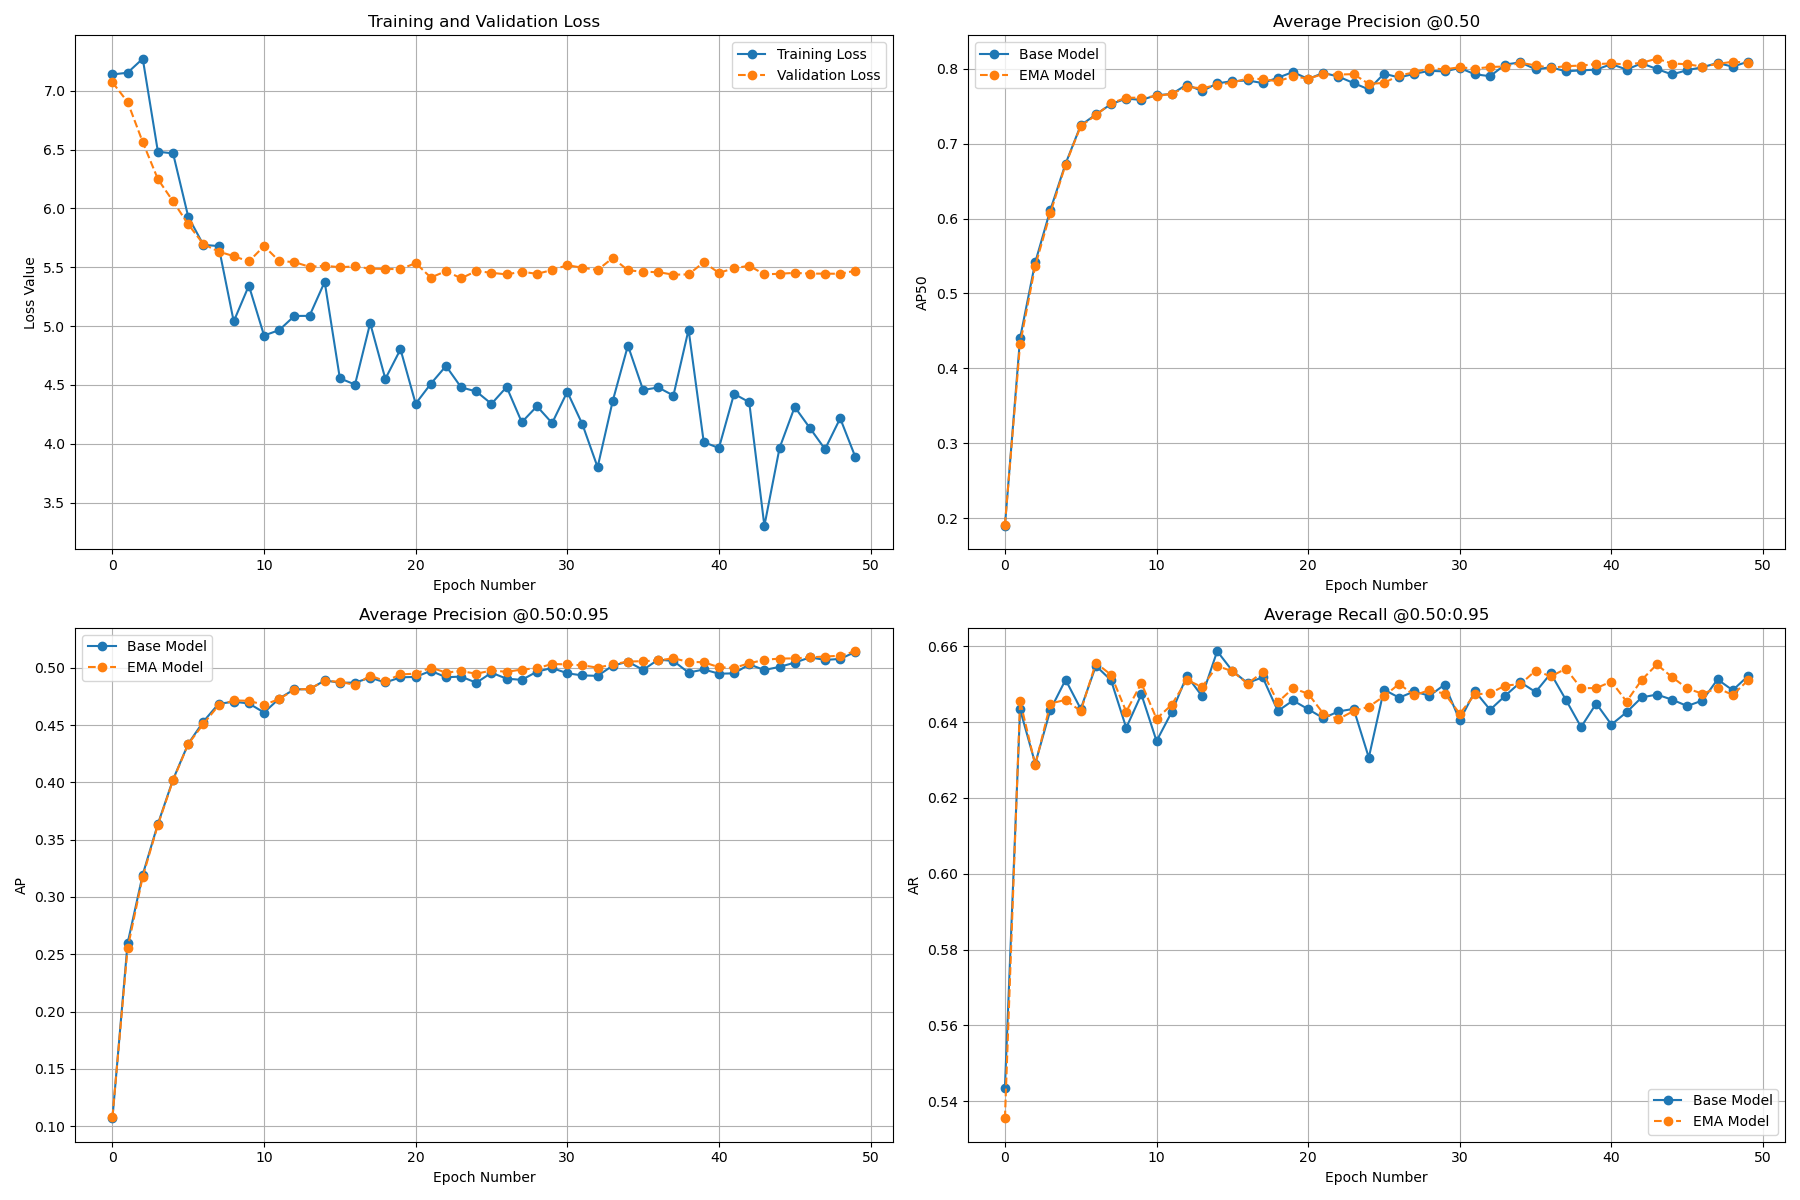

In [9]:
from PIL import Image

Image.open("D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\metrics_plot.png")


In [10]:
import gc
import torch
import weakref

def cleanup_gpu_memory(obj=None, verbose: bool = False):

    if not torch.cuda.is_available():
        if verbose:
            print("[INFO] CUDA is not available. No GPU cleanup needed.")
        return

    def get_memory_stats():
        allocated = torch.cuda.memory_allocated()
        reserved = torch.cuda.memory_reserved()
        return allocated, reserved

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[Before] Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

    # Ensure we drop all strong references
    if obj is not None:
        ref = weakref.ref(obj)
        del obj
        if ref() is not None and verbose:
            print("[WARNING] Object not fully garbage collected yet.")

    gc.collect()
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()

    torch.cuda.synchronize()

    if verbose:
        alloc, reserv = get_memory_stats()
        print(f"[After]  Allocated: {alloc / 1024**2:.2f} MB | Reserved: {reserv / 1024**2:.2f} MB")

In [11]:
cleanup_gpu_memory(model, verbose=True)

[Before] Allocated: 271.58 MB | Reserved: 5212.00 MB
[WARNING] Object not fully garbage collected yet.
[After]  Allocated: 271.58 MB | Reserved: 404.00 MB


In [12]:
model = RFDETRBase(pretrain_weights="D:\\Ruturaj\\New folder (3)\\Ruturaj\\Smart Systems\\rfdetr\\RFDETR\\aquatic_multilayer_output\\checkpoint_best_total.pth")

Loading pretrain weights


In [13]:
import supervision as sv

ds = sv.DetectionDataset.from_coco(
    images_directory_path=f"{DATASET_DIR}/test",
    annotations_path=f"{DATASET_DIR}/test/_annotations.coco.json",
)

In [14]:
import supervision as sv
from tqdm import tqdm
from supervision.metrics import MeanAveragePrecision

model.optimize_for_inference()
targets = []
predictions = []

for path, image, annotations in tqdm(ds):
    # Open and convert image to RGB (ensures 3 channels)
    image = Image.open(path) # This fixes the channel issue
    detections = model.predict(image, threshold=0)

    targets.append(annotations)
    predictions.append(detections)


`loss_type=None` was set in the config but it is unrecognised.Using the default loss: `ForCausalLMLoss`.
100%|██████████| 63/63 [00:08<00:00,  7.27it/s]


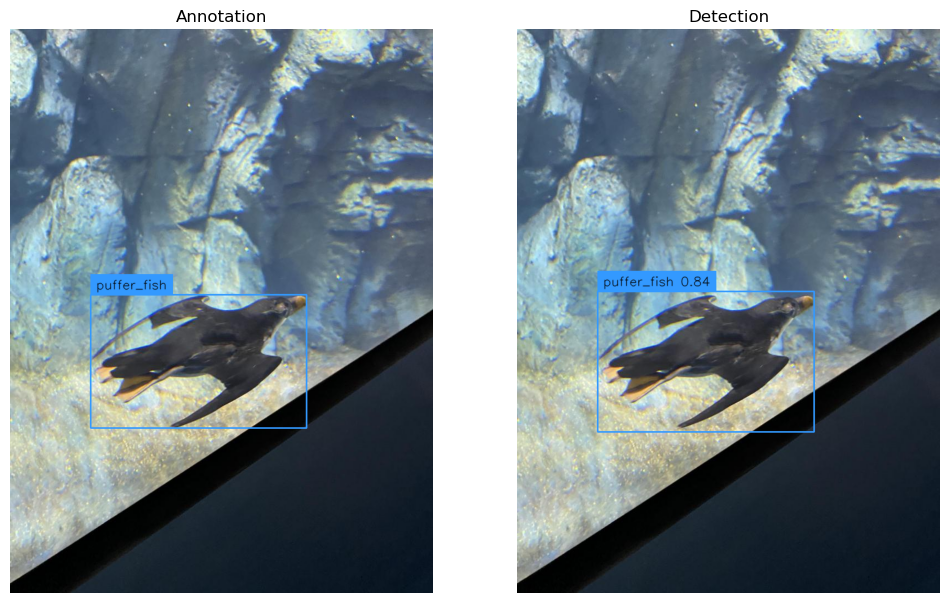

In [15]:
from rfdetr import RFDETRBase
import supervision as sv
from PIL import Image

path, image, annotations = ds[0]
image = Image.open(path)

detections = model.predict(image, threshold=0.5)

text_scale = sv.calculate_optimal_text_scale(resolution_wh=image.size)
thickness = sv.calculate_optimal_line_thickness(resolution_wh=image.size)
color = sv.ColorPalette.from_hex([
    "#ffff00", "#ff9b00", "#ff66ff", "#3399ff", "#ff66b2", "#ff8080",
    "#b266ff", "#9999ff", "#66ffff", "#33ff99", "#66ff66", "#99ff00"
])

bbox_annotator = sv.BoxAnnotator(color=color,thickness=thickness)
label_annotator = sv.LabelAnnotator(
    color=color,
    text_color=sv.Color.BLACK,
    text_scale=text_scale)

annotations_labels = [
    f"{ds.classes[class_id]}"
    for class_id
    in annotations.class_id
]

detections_labels = [
    f"{ds.classes[class_id]} {confidence:.2f}"
    for class_id, confidence
    in zip(detections.class_id, detections.confidence)
]

annotation_image = image.copy()
annotation_image = bbox_annotator.annotate(annotation_image, annotations)
annotation_image = label_annotator.annotate(annotation_image, annotations, annotations_labels)

detections_image = image.copy()
detections_image = bbox_annotator.annotate(detections_image, detections)
detections_image = label_annotator.annotate(detections_image, detections, detections_labels)

sv.plot_images_grid(images=[annotation_image, detections_image], grid_size=(1, 2), titles=["Annotation", "Detection"])